In [1]:
%pip install -q otter-grader

You should consider upgrading via the '/Users/rachel/repos/DS701-Materials-FA26/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


# Case Study 08: Prioritizing Breast Biopsies with Trees and Forests

**DS701 — Session 9 (Mon Oct 5, 2026) — Section A1**

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tools4ds/DS701-Materials-FA26/blob/main/class_activity_notebooks/08-InClass-Exercise-Decision-Trees-A1/08-InClass-Exercise-Decision-Trees-A1.ipynb)

**Time: ~35 minutes.** Work in groups of 2-3.

All parts are **autograded** and submitted to Gradescope. You may use AI assistance, but you must be able to explain and
justify every part of your solution when asked.

**Plan**

| Part | The clinical team's question | Method | Grading | Time |
|---|---|---|---|---|
| 1 | Which single measurement separates benign from malignant, and at what cutoff? | Gini impurity by hand; the continuous-attribute sweep | autograded | ~12 min |
| 2 | How complex can a tree get before it memorizes patients? | Train vs test accuracy as depth grows | autograded | ~8 min |
| 3 | Is a forest worth giving up a readable tree? | Random forest, OOB, importances, `max_features` | autograded | ~12 min |
| — | Report out: what you would tell the clinical team | Team discussion, then pair-share | not graded | ~5 min |

Dependencies: `numpy`, `pandas`, `matplotlib`, `scikit-learn`.

## Case Study Setup

You are a clinical research data scientist working with a consortium of Boston
research hospitals. Their breast-imaging centers perform thousands of
**fine-needle aspirate (FNA)** biopsies a year: a thin needle draws cells from a
breast mass, and a pathologist examines a digitized image of the cell nuclei to
decide whether the mass is **benign or malignant**. Review queues are long, and the
consortium wants to know: *can the nucleus measurements their imaging software
already extracts flag likely-malignant samples reliably enough to prioritize them
for review — and can that be done with a rule a pathologist can read and check?*

Before any of their own patients' data is released to you (that takes IRB
approval), they have asked you to build a prototype on the public **Wisconsin
Diagnostic Breast Cancer** dataset, collected at the University of Wisconsin
Hospitals from the same kind of FNA images. It ships with `scikit-learn`, so nothing
is downloaded:

- **569 samples** — 212 malignant, 357 benign.
- **30 features**: 10 measurements of the cell nuclei in each image (radius, texture,
  perimeter, area, smoothness, compactness, concavity, concave points, symmetry,
  fractal dimension), each summarized three ways — the `mean`, the standard
  `error`, and the `worst` (mean of the three largest nuclei).
- **Label**: `0` = malignant, `1` = benign. Note the coding: malignant, the class the
  clinicians care most about, is `0`.

**What the clinical team asked you, and where you answer it**

1. *Which single measurement best separates benign from malignant, and at what
   cutoff?* — Part 1
2. *How complex can a decision tree get before it starts memorizing these patients
   instead of learning from them?* — Part 2
3. *Is a random forest accurate enough to justify giving up a readable tree, and which
   measurements does it rely on?* — Part 3

A prototype for discussion, not a clinical tool: nothing here is validated for
patient care.

The train/test split, the feature swept in Part 1 and the random-forest randomness
are all fixed by the seed below.

Run the next four cells as-is — everything below depends on them.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Lecture section. Only A1 runs this semester; this is kept because the build
# script reads it to name the variant directory the notebook is published in.
SECTION = "A1"
SEED = 701           # model randomness + noise draws
SPLIT_SEED = 701     # this section's train/test split
RANDOM_STATE = SEED                              # pass this to every sklearn model
rng = np.random.default_rng(SEED)

# The single feature each section sweeps by hand in Part 1 (it is also the
# feature that section's forest will like most in Part 3 -- not a coincidence).
FEATURE = "worst perimeter"

In [4]:
# Colab: fetch the autograder tests for this activity.
import os, sys, urllib.request

if "google.colab" in sys.modules:
    os.makedirs("tests", exist_ok=True)
    BASE = "https://raw.githubusercontent.com/tools4ds/DS701-Materials-FA26/main/class_activity_notebooks/08-InClass-Exercise-Decision-Trees-A1/tests/"
    for _q in ("q1", "q2", "q3", "q4", "q5", "q6", "q7", "q8"):
        urllib.request.urlretrieve(BASE + _q + ".py", "tests/" + _q + ".py")

In [5]:
# Initialize Otter
import otter
grader = otter.Notebook()

In [6]:
data = load_breast_cancer(as_frame=True)
X = data.data                      # DataFrame, 30 columns
y = data.target.to_numpy()         # 1 = benign, 0 = malignant

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SPLIT_SEED, stratify=y
)

print(f"Section {SECTION}")
print(f"features:      {X.shape[1]}")
print(f"train / test:  {len(X_train)} / {len(X_test)}")
print(f"benign share:  train {y_train.mean():.3f}, test {y_test.mean():.3f}")
print(f"Part 1 sweeps: {FEATURE!r}")
X_train.head()

Section A1
features:      30
train / test:  398 / 171
benign share:  train 0.628, test 0.626
Part 1 sweeps: 'worst perimeter'


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
430,14.900,22.53,102.10,685.0,0.09947,0.22250,0.27330,0.09711,0.2041,0.06898,...,16.35,27.57,125.40,832.7,0.1419,0.7090,0.90190,0.24750,0.2866,0.11550
49,13.490,22.30,86.91,561.0,0.08752,0.07698,0.04751,0.03384,0.1809,0.05718,...,15.15,31.82,99.00,698.8,0.1162,0.1711,0.22820,0.12820,0.2871,0.06917
142,11.430,17.31,73.66,398.0,0.10920,0.09486,0.02031,0.01861,0.1645,0.06562,...,12.78,26.76,82.66,503.0,0.1413,0.1792,0.07708,0.06402,0.2584,0.08096
339,23.510,24.27,155.10,1747.0,0.10690,0.12830,0.23080,0.14100,0.1797,0.05506,...,30.67,30.73,202.40,2906.0,0.1515,0.2678,0.48190,0.20890,0.2593,0.07738
273,9.742,15.67,61.50,289.9,0.09037,0.04689,0.01103,0.01407,0.2081,0.06312,...,10.75,20.88,68.09,355.2,0.1467,0.0937,0.04043,0.05159,0.2841,0.08175


## Part 1 (autograded): find the single best cutoff

**Why.** The clinicians' first question is whether *one* measurement, with one cutoff,
already separates benign from malignant samples — a rule a pathologist could check at
the microscope ("is the worst perimeter above $\tau$?"). That rule is exactly a
depth-1 decision tree, and a tree chooses its question by asking which split leaves
the two groups of patients the least *mixed*. Before you trust `scikit-learn` to make
that choice, you build the scoring yourself.

Recall the definition from lecture, for a node $t$ with $c$ classes:

$$\textnormal{Gini}(t) = 1 - \sum_{i=0}^{c-1} p_i(t)^2$$

and the **collective (weighted) impurity** of a binary split into children
$v_L, v_R$:

$$I(\textnormal{children}) = \frac{N(v_L)}{N} I(v_L) + \frac{N(v_R)}{N} I(v_R)$$

**Task 1a — score how mixed a group of patients is.** Gini is 0 when every sample in a
node has the same diagnosis and largest when benign and malignant are evenly mixed.
The weighted version is needed because a split rarely produces equal-sized groups: a
small, pure group of 5 patients should not count as much as an impure group of 300.

Implement both with `numpy`. `gini` takes an array-like of **class
counts** (not probabilities) and must handle an empty node (return `0.0`) and any
number of classes.

In [13]:
def gini(counts):
    """Gini impurity of a node described by its class counts.

    counts: the number of samples of each class in the node, one entry per class,
    e.g. [n_malignant, n_benign]. Counts, not probabilities. Any number of classes.

    Examples:
        gini([6, 0])     -> 0.0     # pure node: every sample has the same diagnosis
        gini([3, 3])     -> 0.5     # evenly mixed binary node
        gini([2, 2, 2])  -> 0.6667  # three classes evenly mixed: 1 - 3 * (1/3)**2
        gini([0, 0])     -> 0.0     # empty node: return 0.0, don't divide by zero
    """
    total = sum(counts)
    if total == 0:
        return 0.0
    return 1.0 - sum((count / total) ** 2 for count in counts)


def weighted_gini(left_counts, right_counts):
    """Weighted average Gini impurity of the two children of a binary split.

    left_counts, right_counts: class counts in each child, in the same class order
    as gini(). Each child is weighted by its share of the samples.

    Examples:
        weighted_gini([5, 0], [0, 7])  -> 0.0   # perfect split: both children pure
        weighted_gini([2, 2], [2, 2])  -> 0.5   # separates nothing: same as gini([4, 4])
        weighted_gini([3, 0], [1, 1])  -> 0.2   # (3/5) * 0.0 + (2/5) * 0.5
    """
    total_samples = sum(left_counts) + sum(right_counts)
    left_weight = sum(left_counts) / total_samples if total_samples > 0 else 0
    right_weight = sum(right_counts) / total_samples if total_samples > 0 else 0
    return left_weight * gini(left_counts) + right_weight * gini(right_counts)


print("Gini of a 50/50 node   :", gini([3, 3]))
print("example root node (3 Yes, 7 No):", round(gini([3, 7]), 4))
print("child node counts after split by some attribute :", round(weighted_gini([0, 3], [3, 4]), 4))

Gini of a 50/50 node   : 0.5
example root node (3 Yes, 7 No): 0.42
child node counts after split by some attribute : 0.3429


In [15]:
grader.check("q1")

q1 results: All test cases passed!

**Task 1b — search for the cutoff.** The nucleus measurements are continuous, so
there is no natural set of cutoffs to try; the tree has to search for one. This sweep
is how it does that, and its output is the cutoff you would hand the pathologists.
Implement the continuous-attribute sweep from lecture:

1. sort the distinct values of the feature,
2. take candidate thresholds **midway between consecutive distinct values**,
3. score each with `weighted_gini` (left child = `x <= tau`),
4. return the threshold with the **lowest** weighted impurity.

Then run it on this section's `FEATURE` and store the results in `best_thr` and
`best_score`. The public check fits a depth-1 `DecisionTreeClassifier` on the same
single column and confirms that you found *exactly* the same split `scikit-learn` did.
Once it passes, you can tell the clinical team: *"On `FEATURE` alone, a cutoff of
`best_thr` gives the purest split we can find."*

In [18]:
def best_split_for_feature(x, labels, n_classes=2):
    """Return (best_threshold, best_weighted_gini) for one continuous feature.

    x: the feature's value for each sample, e.g. one column of X_train.
    labels: each sample's class as an integer 0 .. n_classes-1
        (here 0 = malignant, 1 = benign), same length as x.
    A threshold tau sends samples with x <= tau to the left child.

    Examples:
        best_split_for_feature([1, 2, 3, 4], [0, 0, 1, 1])  -> (2.5, 0.0)
            # candidates 1.5, 2.5, 3.5; tau = 2.5 separates the classes perfectly
        best_split_for_feature([5, 5, 7, 9], [0, 0, 1, 1])  -> (6.0, 0.0)
            # midpoints between *distinct* values only: 6.0 and 8.0
        best_split_for_feature([1, 2, 3, 4], [0, 1, 0, 1])  -> (1.5, 0.3333)
            # 1.5 and 3.5 tie at 1/3; keep the first (lowest) threshold
    """
    x = np.asarray(x, dtype=float)
    labels = np.asarray(labels, dtype=int)
    distinct_values = np.unique(x)
    thresholds = (distinct_values[:-1] + distinct_values[1:]) / 2

    if thresholds.size == 0:
        counts = np.bincount(labels, minlength=n_classes)
        return None, gini(counts)

    best_threshold = thresholds[0]
    best_score = float("inf")
    for threshold in thresholds:
        left = x <= threshold
        left_counts = np.bincount(labels[left], minlength=n_classes)
        right_counts = np.bincount(labels[~left], minlength=n_classes)
        score = weighted_gini(left_counts, right_counts)
        if score < best_score:
            best_threshold = threshold
            best_score = score

    return float(best_threshold), float(best_score)


best_thr, best_score = best_split_for_feature(X_train[FEATURE], y_train)

root_gini = gini(np.bincount(y_train, minlength=2))
print(f"root Gini                : {root_gini:.6f}")
print(f"best threshold           : {FEATURE} <= {best_thr}")
print(f"weighted child Gini      : {best_score:.6f}")
print(f"Gini gain                : {root_gini - best_score:.6f}")

root Gini                : 0.467160
best threshold           : worst perimeter <= 113.75
weighted child Gini      : 0.146339
Gini gain                : 0.320821


In [19]:
grader.check("q2")

q2 results: All test cases passed!

## Part 2 (autograded): how deep should the tree go?

**Why.** One cutoff is readable but probably not accurate enough, so the natural next
step is to let the tree ask more questions. Grow it far enough and it will classify
every *training* patient perfectly — but the consortium will apply it to *next month's*
patients, not these. The test set stands in for those future patients. You are
looking for the depth where the tree stops learning patterns that generalize and
starts memorizing individual patients. A deep tree is also no longer something a
pathologist can read, so complexity has a cost even before it hurts accuracy.

For each depth in `DEPTHS`, fit a `DecisionTreeClassifier(max_depth=d,
random_state=RANDOM_STATE)` on the **training** set and record training and
test accuracy.

Build a DataFrame `depth_results` with **exactly** the columns
`["max_depth", "train_acc", "test_acc"]`, one row per depth in order, then set:

- `best_depth` — the `max_depth` with the highest test accuracy (as an `int`),
- `best_tree_test_acc` — that test accuracy,
- `full_tree` — a tree fit with `max_depth=None` (grown until every leaf is pure).

In [25]:
DEPTHS = [1, 2, 3, 4, 5, 6, 8, 12]

results = []
for depth in DEPTHS:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    results.append({
        "max_depth": depth,
        "train_acc": tree.score(X_train, y_train),
        "test_acc": tree.score(X_test, y_test),
    })

depth_results = pd.DataFrame(results, columns=["max_depth", "train_acc", "test_acc"])
best_row = depth_results["test_acc"].idxmax()
best_depth = int(depth_results.loc[best_row, "max_depth"])
best_tree_test_acc = depth_results.loc[best_row, "test_acc"]
full_tree = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
full_tree.fit(X_train, y_train)

depth_results["gap"] = depth_results["train_acc"] - depth_results["test_acc"]
print(depth_results.to_string(index=False))
print(f"\nbest depth by test accuracy: {best_depth} "
      f"(test acc {best_tree_test_acc:.4f})")
print(f"fully grown tree: depth {full_tree.get_depth()}, "
      f"train {full_tree.score(X_train, y_train):.4f}, "
      f"test {full_tree.score(X_test, y_test):.4f}")

 max_depth  train_acc  test_acc      gap
         1   0.919598  0.912281 0.007317
         2   0.924623  0.912281 0.012342
         3   0.974874  0.941520 0.033354
         4   0.987437  0.929825 0.057613
         5   0.989950  0.935673 0.054277
         6   0.994975  0.923977 0.070998
         8   1.000000  0.929825 0.070175
        12   1.000000  0.929825 0.070175

best depth by test accuracy: 3 (test acc 0.9415)
fully grown tree: depth 8, train 1.0000, test 0.9298


In [26]:
grader.check("q3")

q3 results: All test cases passed!

Plot the two accuracy curves — this cell is given, just run it. Look at *where* the
test curve peaks and where the gap opens — which depths are high bias, and which high
variance? Which depth would you recommend to the clinical team, and how many questions
would a pathologist have to follow to read it?

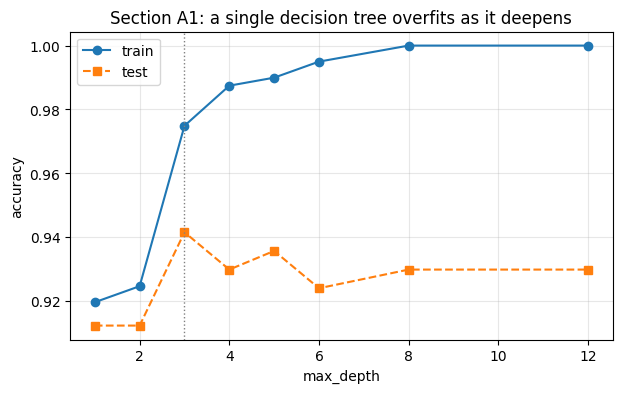

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depth_results["max_depth"], depth_results["train_acc"],
        "o-", label="train")
ax.plot(depth_results["max_depth"], depth_results["test_acc"],
        "s--", label="test")
ax.axvline(best_depth, color="grey", lw=1, ls=":")
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_title(f"Section {SECTION}: a single decision tree overfits as it deepens")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Part 3 (autograded): is a forest worth giving up a readable tree?

**Why.** A random forest averages hundreds of trees, which usually beats any single tree
— but no pathologist can read 300 trees. The clinical team needs to know what that
trade buys them, and which measurements the forest relies on, so they can judge
whether it agrees with their own clinical sense.

**Task 3a — baseline forest.** First measure what the forest gains. Fit
`RandomForestClassifier(n_estimators=300, oob_score=True, random_state=RANDOM_STATE)`
on the training set and set:

- `rf` — the fitted model,
- `rf_train_acc`, `rf_test_acc` — accuracies,
- `rf_oob` — the out-of-bag score `rf.oob_score_` (each tree omits ~37% of the rows;
  scoring every row only with the trees that never saw it gives a validation estimate
  for free — valuable when you only have 569 patients and every one held out for
  testing is one fewer to learn from),
- `importances` — which measurements the forest leans on: a `pd.Series` of `rf.feature_importances_` **indexed by
  feature name**, sorted descending,
- `top5` — a list of the 5 most important feature names, most important first.

In [ ]:
...

print(f"random forest  train {rf_train_acc:.4f}  OOB {rf_oob:.4f}  test {rf_test_acc:.4f}")
print(f"best single tree (depth {best_depth}) test {best_tree_test_acc:.4f}")
print("\ntop 5 features:")
print(importances.head(5).to_string())

In [ ]:
grader.check("q4")

Plot the top 10 importances. Given — just run it. Is your Part 1 `FEATURE` near the
top? Which *kind* of measurement dominates (size, shape, texture), and would a
pathologist find that plausible?

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
importances.head(10)[::-1].plot.barh(ax=ax)
ax.set_xlabel("impurity-based importance")
ax.set_title(f"Section {SECTION}: random forest, top 10 features")
plt.tight_layout()
plt.show()

**Task 3b — `max_features`: the ingredient the lecture skipped.**

**Why.** If you recommend a forest, you need to know which settings matter. On this
data a few size measurements (perimeter, radius, area) are strong and highly
correlated; if every tree is free to split on them, every tree looks much the same and
the forest is little better than one tree repeated 300 times. This task measures how
the forest avoids that.

The lecture's random forest bootstraps the *rows*. `scikit-learn`'s forest also does
something at **every split of every tree**: it considers only a random subset of
`max_features` of the $p$ columns (default `"sqrt"`, i.e. $\sqrt{30} \approx 5$ here).
Bagging alone leaves the trees *correlated* — if one feature dominates, every tree
splits on it at the root — and averaging correlated predictors buys little.
Feature subsampling forces the trees apart.

Measure that directly. For each `m` in `MAX_FEATURES`, fit
`RandomForestClassifier(n_estimators=300, max_features=m, oob_score=True,
random_state=RANDOM_STATE)` and record, in a DataFrame `mf_results` with **exactly**
the columns `["max_features", "oob_score", "test_acc", "mean_tree_acc", "mean_tree_corr"]`
(one row per `m`, in order):

- `oob_score` — the forest's out-of-bag score,
- `test_acc` — the forest's test accuracy,
- `mean_tree_acc` — the **average test accuracy of the individual trees**
  (`forest.estimators_`), i.e. how good one tree is on its own,
- `mean_tree_corr` — the **average pairwise correlation between the individual trees'
  test-set predictions**, i.e. how alike the trees are.

To do that, first implement `per_tree_predictions(forest, X)`: return an integer array of
shape `(n_trees, n_samples)` whose row $i$ is `forest.estimators_[i].predict(...)`.
The individual trees were fit on plain arrays, so pass `X.to_numpy()` to avoid
feature-name warnings. The correlation helper `mean_pairwise_corr` is given.

In [ ]:
MAX_FEATURES = [1, 2, 5, 10, 20, 30]     # 5 ~ sqrt(30) is the default; 30 = all = plain bagging


def mean_pairwise_corr(P):
    """Mean off-diagonal Pearson correlation between the rows of P (n_trees, n_samples)."""
    C = np.corrcoef(P.astype(float))
    iu = np.triu_indices_from(C, k=1)
    return float(np.nanmean(C[iu]))


def per_tree_predictions(forest, X):
    """(n_trees, n_samples) array: row i holds the predictions of forest.estimators_[i]."""
    ...


...

print(mf_results.round(4).to_string(index=False))

In [ ]:
grader.check("q5")

Plot it (given). Left: individual trees get *better* but *more alike* as `max_features`
grows. Right: the ensemble's OOB and test accuracy — note where the default `sqrt` sits.
For the clinical team: does tuning this knob change your recommendation, or is the
default good enough?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(mf_results["max_features"], mf_results["mean_tree_acc"], "o-", label="mean single-tree test acc")
ax.set_xlabel("max_features"); ax.set_ylabel("accuracy"); ax.grid(alpha=0.3)
ax2 = ax.twinx()
ax2.plot(mf_results["max_features"], mf_results["mean_tree_corr"], "s--", color="C3",
         label="mean pairwise tree correlation")
ax2.set_ylabel("correlation", color="C3")
ax.set_title("individual trees: stronger but more alike")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="lower right", fontsize=8)

ax = axes[1]
ax.plot(mf_results["max_features"], mf_results["oob_score"], "o-", label="forest OOB score")
ax.plot(mf_results["max_features"], mf_results["test_acc"], "s--", label="forest test acc")
ax.axvline(5, color="grey", lw=1, ls=":", label="sqrt(30) default")
ax.set_xlabel("max_features"); ax.set_ylabel("accuracy"); ax.grid(alpha=0.3)
ax.set_title("the ensemble")
ax.legend(fontsize=8)
plt.suptitle(f"Section {SECTION}: what max_features does")
plt.tight_layout()
plt.show()

## Report out: what would you tell the clinical team?

Discuss as a team (~3 min), then write your answers in the cell below. These are not
graded, but staff will ask about them, and they are what you will share.

1. **The answers they asked for.** One sentence each, with numbers from your notebook:
   the best single cutoff (Part 1), the tree depth you would recommend (Part 2), and
   whether the forest is worth giving up a readable tree (Part 3).
2. **Your takeaway.** What is the one thing this study taught you — about trees,
   about overfitting, or about turning a model into advice someone will act on — that
   you would want the rest of the class to hear?

**Pair-share (~2 min).** Turn to a neighboring team and compare: did you make the same
recommendation? If not, whose evidence is stronger? Be ready to share one takeaway
with the class.

**Submit.** Run all cells top to bottom, confirm every `grader.check(...)` cell passes,
and submit this notebook to the Gradescope assignment **Activity 08 (Section A1)**.

*Not covered today but worth knowing:* `max_features` also exists on a *single*
`DecisionTreeClassifier`, and impurity-based importances like the ones you plotted in
Part 3 can mislead — see `sklearn.inspection.permutation_importance` for an alternative
computed on held-out data.

*Your team's report here (include your team members' names).*

1. Cutoff: 
   Depth: 
   Forest: 
2. Takeaway: 